In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd

print("Tensorflow version : " , tf.__version__)

Tensorflow version :  2.20.0


LOADING AND NORMALISING THE CIFAR10 DATASET



In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


ANN MODEL WITH INCREASED LAYERS

In [3]:
ann_model = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),

    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

TRAINING ANN USING 10 EPOCHS

In [4]:
history_ann = ann_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.2317 - loss: 2.0789 - val_accuracy: 0.3132 - val_loss: 1.9059
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2828 - loss: 1.9338 - val_accuracy: 0.3296 - val_loss: 1.8403
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3012 - loss: 1.8902 - val_accuracy: 0.3323 - val_loss: 1.8368
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3070 - loss: 1.8700 - val_accuracy: 0.3573 - val_loss: 1.8309
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3221 - loss: 1.8494 - val_accuracy: 0.3658 - val_loss: 1.8047
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3269 - loss: 1.8315 - val_accuracy: 0.3710 - val_loss: 1.8078
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3234 - loss: 1.8306 - val_accuracy: 0.3681 - val_loss: 1.8036
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3333 - loss: 1.8116 - val_accuracy: 

CNN MODEL(32 -> 64 -> 128)

In [5]:
cnn_model = models.Sequential([

    layers.Conv2D(32,(3,3),padding='same',
                  activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),padding='same',
                  activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),padding='same',
                  activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

TRAINING CNN(10 EPOCHS)

In [6]:
history_cnn = cnn_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.4304 - loss: 1.6163 - val_accuracy: 0.1854 - val_loss: 4.5025
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5713 - loss: 1.1989 - val_accuracy: 0.5352 - val_loss: 1.3426
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6460 - loss: 1.0173 - val_accuracy: 0.6448 - val_loss: 1.0092
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6848 - loss: 0.8914 - val_accuracy: 0.5566 - val_loss: 1.5946
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7219 - loss: 0.7963 - val_accuracy: 0.6490 - val_loss: 1.1067
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7492 - loss: 0.7139 - val_accuracy: 0.6655 - val_loss: 1.0233
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7757 - loss: 0.6336 - val_accuracy: 0.7316 - val_loss: 0.7999
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7958 - loss: 0.5710 - val_accuracy:

ACCURACY CURVES(ANN vs CNN)

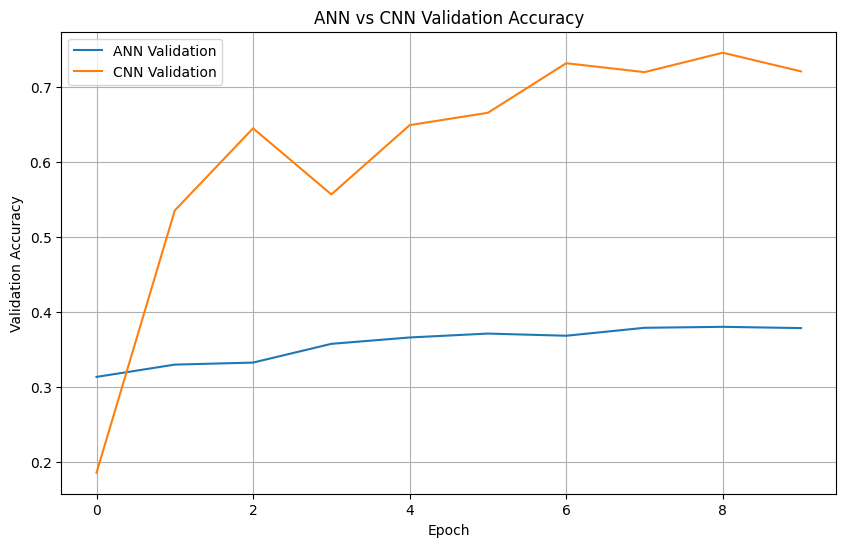

In [7]:
plt.figure(figsize=(10,6))

plt.plot(history_ann.history['val_accuracy'],
         label='ANN Validation')

plt.plot(history_cnn.history['val_accuracy'],
         label='CNN Validation')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

In [8]:
ann_loss, ann_acc = ann_model.evaluate(x_test,y_test)

cnn_loss, cnn_acc = cnn_model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3863 - loss: 1.7444
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7112 - loss: 0.9447


DATA AUGMENTATION

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

ADV CNN AND AUGMENTATION

In [10]:
advanced_model = models.Sequential([

    data_augmentation,

    layers.Conv2D(64,(3,3),
                  activation='relu',
                  padding='same',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),

    layers.Conv2D(64,(3,3),
                  activation='relu',
                  padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),
                  activation='relu',
                  padding='same'),
    layers.BatchNormalization(),

    layers.Conv2D(128,(3,3),
                  activation='relu',
                  padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(256,(3,3),
                  activation='relu',
                  padding='same'),
    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(512,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(256,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10,activation='softmax')
])

In [11]:
advanced_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EARLY STOPPING

In [12]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

TRAINING ADVANCE MODEL (20 EPOCHS)

In [13]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
history_advanced = advanced_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.3318 - loss: 1.8890 - val_accuracy: 0.2186 - val_loss: 2.2045
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.4504 - loss: 1.5179 - val_accuracy: 0.5557 - val_loss: 1.3491
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.5325 - loss: 1.3190 - val_accuracy: 0.4479 - val_loss: 1.5910
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5864 - loss: 1.1809 - val_accuracy: 0.6200 - val_loss: 1.1250
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.6248 - loss: 1.0950 - val_accuracy: 0.6440 - val_loss: 1.0562
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.6529 - loss: 1.0094 - val_accuracy: 0.6594 - val_loss: 1.0037
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.6769 - loss: 0.9477 - val_accuracy: 0.6430 - val_loss: 1.0426
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.6945 - loss: 0.9071 - 

In [15]:
adv_loss, adv_acc = advanced_model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7895 - loss: 0.6323


ACCURACY CURVES COMPARSION

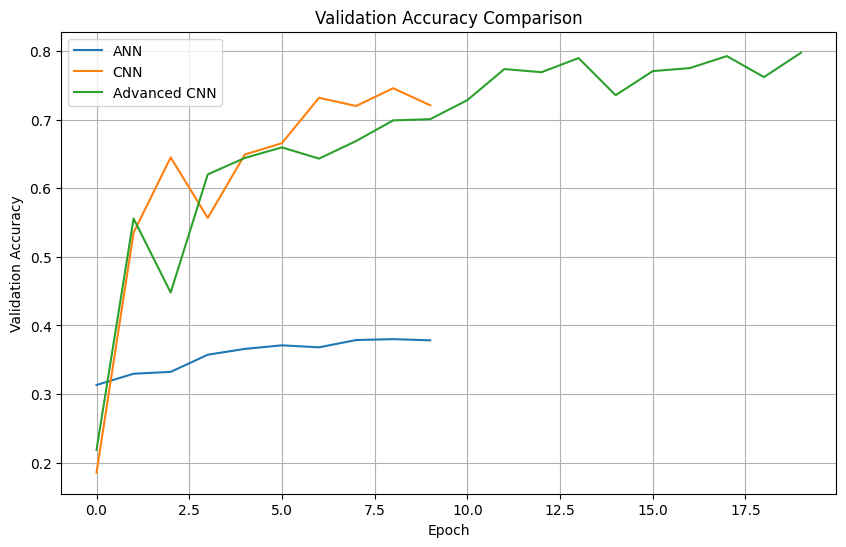

In [16]:
plt.figure(figsize=(10,6))

plt.plot(history_ann.history['val_accuracy'],
         label='ANN')

plt.plot(history_cnn.history['val_accuracy'],
         label='CNN')

plt.plot(history_advanced.history['val_accuracy'],
         label='Advanced CNN')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid()
plt.show()

LOSS CURVES COMPARSION

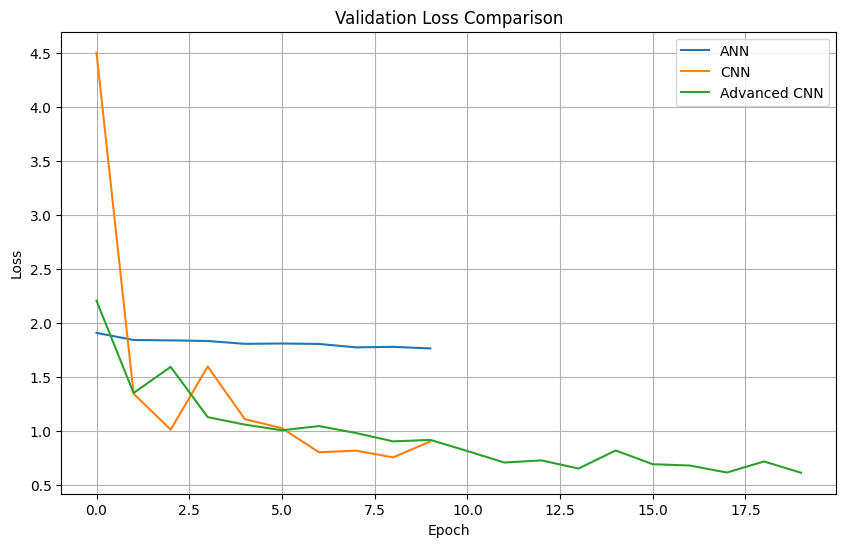

In [17]:
plt.figure(figsize=(10,6))

plt.plot(history_ann.history['val_loss'],
         label='ANN')

plt.plot(history_cnn.history['val_loss'],
         label='CNN')

plt.plot(history_advanced.history['val_loss'],
         label='Advanced CNN')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid()
plt.show()

GENERALISED COMPARSION

In [18]:
generalization_df = pd.DataFrame({

    "Model":[
        "ANN",
        "CNN",
        "Advanced CNN"
    ],

    "Train Accuracy (%)":[
        round(history_ann.history['accuracy'][-1]*100,2),
        round(history_cnn.history['accuracy'][-1]*100,2),
        round(history_advanced.history['accuracy'][-1]*100,2)
    ],

    "Validation Accuracy (%)":[
        round(history_ann.history['val_accuracy'][-1]*100,2),
        round(history_cnn.history['val_accuracy'][-1]*100,2),
        round(history_advanced.history['val_accuracy'][-1]*100,2)
    ]
})

generalization_df

,Model,Train Accuracy (%),Validation Accuracy (%)
0,ANN,34.85,37.83
1,CNN,83.20,72.07
2,Advanced CNN,80.62,79.73


TRAINING STRATEGY COMPARSION

In [19]:
strategy_df = pd.DataFrame({

    "Model":[
        "ANN",
        "CNN",
        "Advanced CNN"
    ],

    "Dropout":[
        "Yes",
        "Yes",
        "Yes"
    ],

    "Batch Normalization":[
        "No",
        "Yes",
        "Yes"
    ],

    "Data Augmentation":[
        "No",
        "No",
        "Yes"
    ],

    "Epochs":[
        10,
        10,
        20
    ]
})

strategy_df

,Model,Dropout,Batch Normalization,Data Augmentation,Epochs
0,ANN,Yes,No,No,10
1,CNN,Yes,Yes,No,10
2,Advanced CNN,Yes,Yes,Yes,20


PERFORMANCE COMPARSION

In [20]:
final_df = pd.DataFrame({

    "Model":[
        "ANN",
        "CNN",
        "Advanced CNN + Augmentation"
    ],

    "Test Accuracy (%)":[
        round(ann_acc*100,2),
        round(cnn_acc*100,2),
        round(adv_acc*100,2)
    ],

    "Generalization":[
        "Moderate",
        "Good",
        "Best"
    ],

    "Training Strategy":[
        "Dropout",
        "Dropout + BatchNorm",
        "Dropout + BatchNorm + Augmentation + EarlyStopping"
    ]
})

final_df

,Model,Test Accuracy (%),Generalization,Training Strategy
0,ANN,38.63,Moderate,Dropout
1,CNN,71.12,Good,Dropout + BatchNorm
2,Advanced CNN + Augmentation,78.95,Best,Dropout + BatchNorm + Augmentation + EarlyStop...


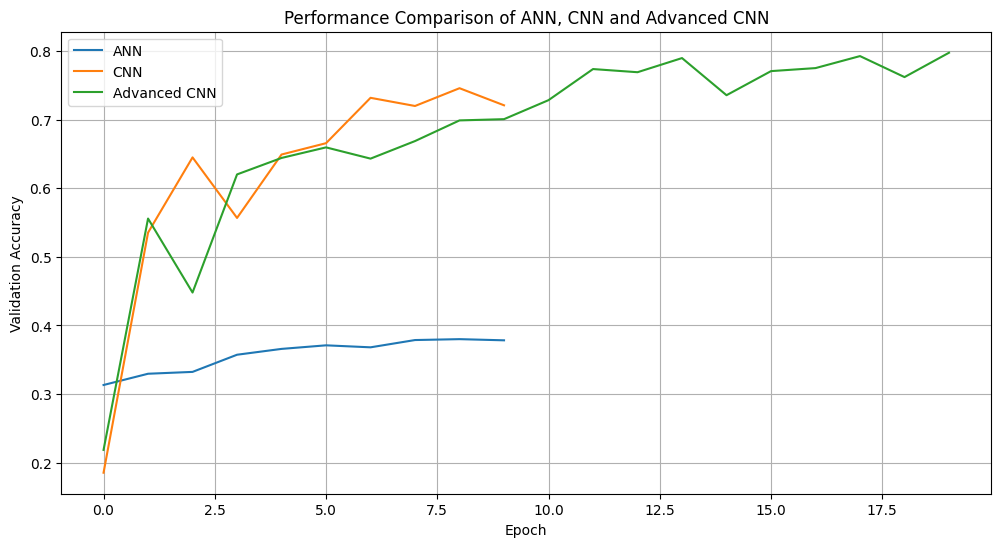

In [21]:
plt.figure(figsize=(12,6))

plt.plot(history_ann.history['val_accuracy'],
         label='ANN')

plt.plot(history_cnn.history['val_accuracy'],
         label='CNN')

plt.plot(history_advanced.history['val_accuracy'],
         label='Advanced CNN')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Performance Comparison of ANN, CNN and Advanced CNN")
plt.legend()
plt.grid()
plt.show()